In [5]:
using CairoMakie
using Printf
#using GLMakie
using IJulia
include("coil_centering_full.jl")
include("tilt_shift.jl")
CairoMakie.activate!()


  Activating project at `~/Documents/GitHub/JULIA_GPEC`


In [2]:
function run_scan(; kwargs...)
    # -----------------------------
    # Defaults
    # -----------------------------
    defaults = (
        shift_x = 0.0,
        shift_y = 0.0,
        shift_z = 0.0,

        tilt_x_deg = 0.0,
        tilt_y_deg = 0.0,
        tilt_z_deg = 0.0,

        current_A = 100.0,

        n_phi_inner = 24,
        n_z_inner   = 22,

        hall_n_phi_outer = nothing,
        hall_n_z_outer   = nothing,

        hall_r_inner_frac       = 0.40,
        hall_r_outer_frac       = 0.50,
        hall_z_halfspan_inner_m = 0.60,
        hall_z_halfspan_outer_m = 0.40,

        field_hall_mode      = :internal,
        physical_hall_mode   = :internal,

        tilt_calibration_radius_m = NaN,
        add_noise_frac            = 0.0,
        br_zero_noise_frac        = 0.0,
        br_min_frac_for_fourier_xy= 0.10,
        bphi_sign                 = 1.0,
        xy_min_step0_m            = 0.050,
        xy_min_tol_m              = 1e-8,
        bias_correction_n_iter    = 4,
        bias_correction_damping   = 0.6,

        enable_axis_plot  = false,
        display_axis_plot = false,

        phys_file  = "sparc_pf1u.dat",
        field_file = "coil_out.dat",
        hall_csv   = "A_Hall_Test.csv",
    )

    # Merge user kwargs into defaults
    p = merge(defaults, kwargs)

    # Auto outer-grid scaling if not explicitly provided
    hall_n_phi_outer = isnothing(p.hall_n_phi_outer) ?
        Int(round(p.n_phi_inner * 0.8)) :
        p.hall_n_phi_outer

    hall_n_z_outer = isnothing(p.hall_n_z_outer) ?
        Int(round(p.n_z_inner * 0.5)) :
        p.hall_n_z_outer

    local_results = nothing

    redirect_stdout(devnull) do

        # ---------------------------------
        # 1) Generate coil geometry
        # ---------------------------------
        transform_coil(
            p.phys_file,
            p.field_file;

            shift_x   = p.shift_x,
            shift_y   = p.shift_y,
            shift_z   = p.shift_z,

            tilt_x_deg = p.tilt_x_deg,
            tilt_y_deg = p.tilt_y_deg,
            tilt_z_deg = p.tilt_z_deg,
        )

        # ---------------------------------
        # 2) Export Hall Data
        # ---------------------------------
        # export_hall_csv_notebook(
        #     coil_file = p.field_file,
        #     out_csv   = p.hall_csv,
        #     current_A = p.current_A
        # )

        # ---------------------------------
        # 3) Full pipeline
        # ---------------------------------
        local_results = run_coil_axis_comparison(

            run_name           = "res_scan",
            script_dir         = @__DIR__,

            coil_current_a     = p.current_A,

            physical_coil_file = joinpath(@__DIR__, p.phys_file),
            field_coil_file    = joinpath(@__DIR__, p.field_file),

            hall_n_phi_inner = p.n_phi_inner,
            hall_n_z_inner   = p.n_z_inner,

            hall_n_phi_outer = hall_n_phi_outer,
            hall_n_z_outer   = hall_n_z_outer,

            hall_r_inner_frac       = p.hall_r_inner_frac,
            hall_r_outer_frac       = p.hall_r_outer_frac,

            hall_z_halfspan_inner_m = p.hall_z_halfspan_inner_m,
            hall_z_halfspan_outer_m = p.hall_z_halfspan_outer_m,

            field_hall_mode         = p.field_hall_mode,
            field_hall_input_csv    = joinpath(@__DIR__, p.hall_csv),
            physical_hall_mode      = p.physical_hall_mode,

            tilt_calibration_radius_m = p.tilt_calibration_radius_m,
            add_noise_frac            = p.add_noise_frac,
            br_zero_noise_frac        = p.br_zero_noise_frac,
            br_min_frac_for_fourier_xy= p.br_min_frac_for_fourier_xy,
            bphi_sign                 = p.bphi_sign,
            xy_min_step0_m            = p.xy_min_step0_m,
            xy_min_tol_m              = p.xy_min_tol_m,
            bias_correction_n_iter    = p.bias_correction_n_iter,
            bias_correction_damping   = p.bias_correction_damping,

            enable_axis_plot          = p.enable_axis_plot,
            display_axis_plot         = p.display_axis_plot,
        )
    end

    phys = local_results.physical_corrected
    fld  = local_results.field_corrected

    dx = (fld.x0 - phys.x0) * 1e3
    dy = (fld.y0 - phys.y0) * 1e3

    dr = sqrt(dx^2 + dy^2)

    return dr, phys, fld, local_results
end

run_scan (generic function with 1 method)

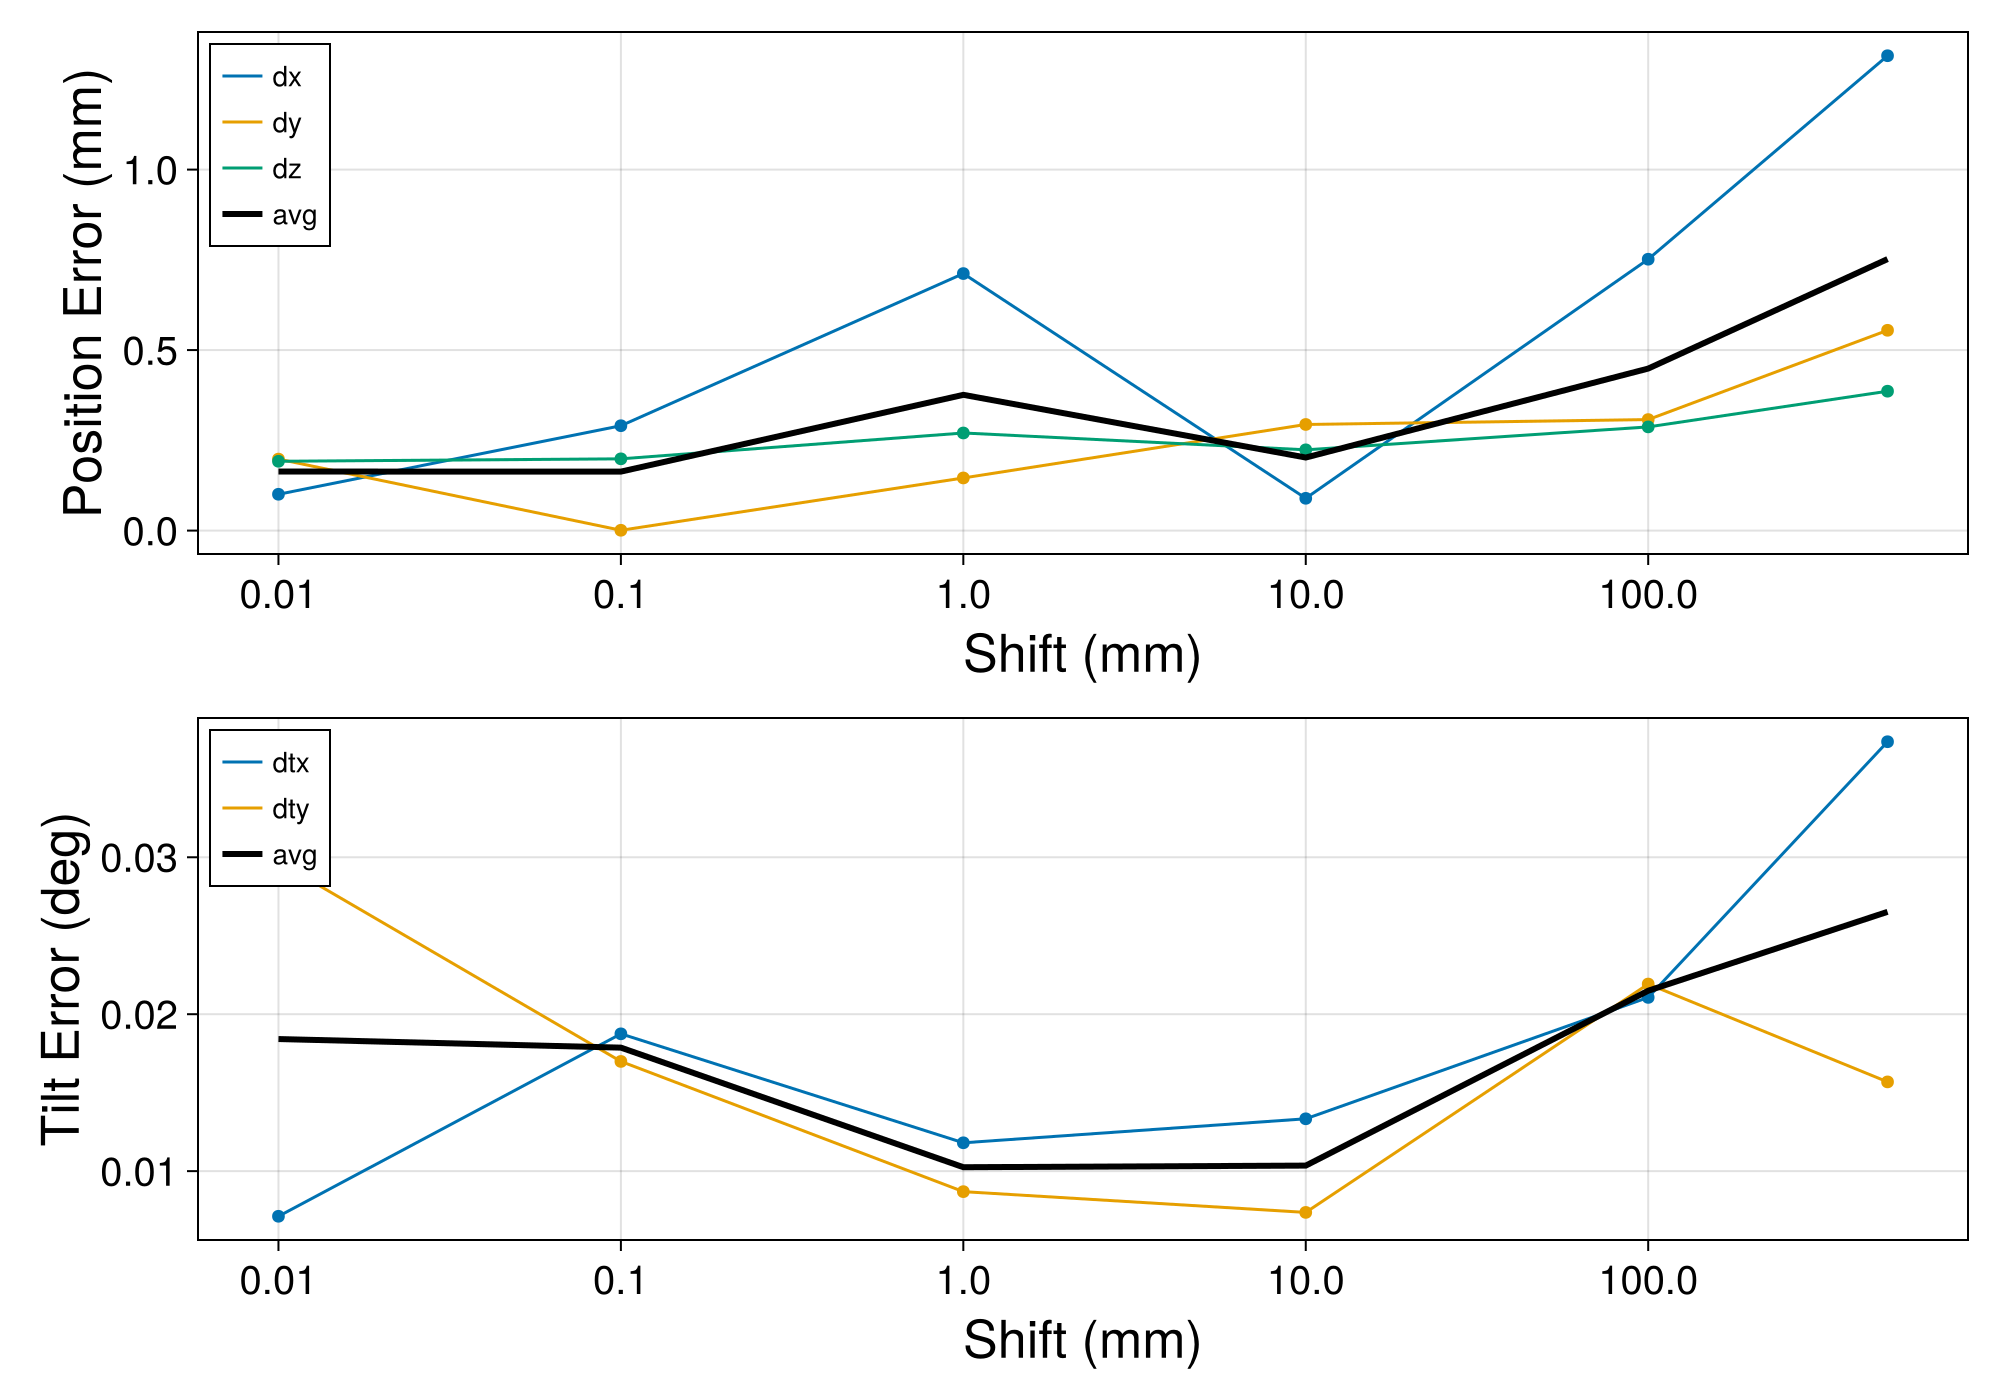

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


CairoMakie.Screen{IMAGE}


In [7]:
shifts = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 5e-1]

dx_mm  = Float64[]
dy_mm  = Float64[]
dz_mm  = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for shift in shifts
    dr, phys, fld = run_scan(
        shift_x=shift,
        shift_y=shift,
        shift_z=shift,
        tilt_x_deg=0.0,
        add_noise_frac = 0.001,
    )

    push!(dx_mm,  abs(fld.x0 - phys.x0 - shift) * 1e3)
    push!(dy_mm,  abs(fld.y0 - phys.y0 - shift) * 1e3)
    push!(dz_mm,  abs(fld.z0 - phys.z0 - shift) * 1e3)
    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y))
end

x_mm = shifts .* 1e3

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Shift (mm)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Shift (mm)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize=ax1.ylabelsize=ax2.xlabelsize=ax2.ylabelsize=26
ax1.xticklabelsize=ax1.yticklabelsize=ax2.xticklabelsize=ax2.yticklabelsize=20

# position components
lines!(ax1, x_mm, dx_mm, label="dx")
scatter!(ax1, x_mm, dx_mm)

lines!(ax1, x_mm, dy_mm, label="dy")
scatter!(ax1, x_mm, dy_mm)

lines!(ax1, x_mm, dz_mm, label="dz")
scatter!(ax1, x_mm, dz_mm)

lines!(ax1, x_mm, pos_avg, label="avg", linewidth=3, color=:black)


# tilt components
lines!(ax2, x_mm, dtx_deg, label="dtx")
scatter!(ax2, x_mm, dtx_deg)

lines!(ax2, x_mm, dty_deg, label="dty")
scatter!(ax2, x_mm, dty_deg)

lines!(ax2, x_mm, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
fig
display(fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


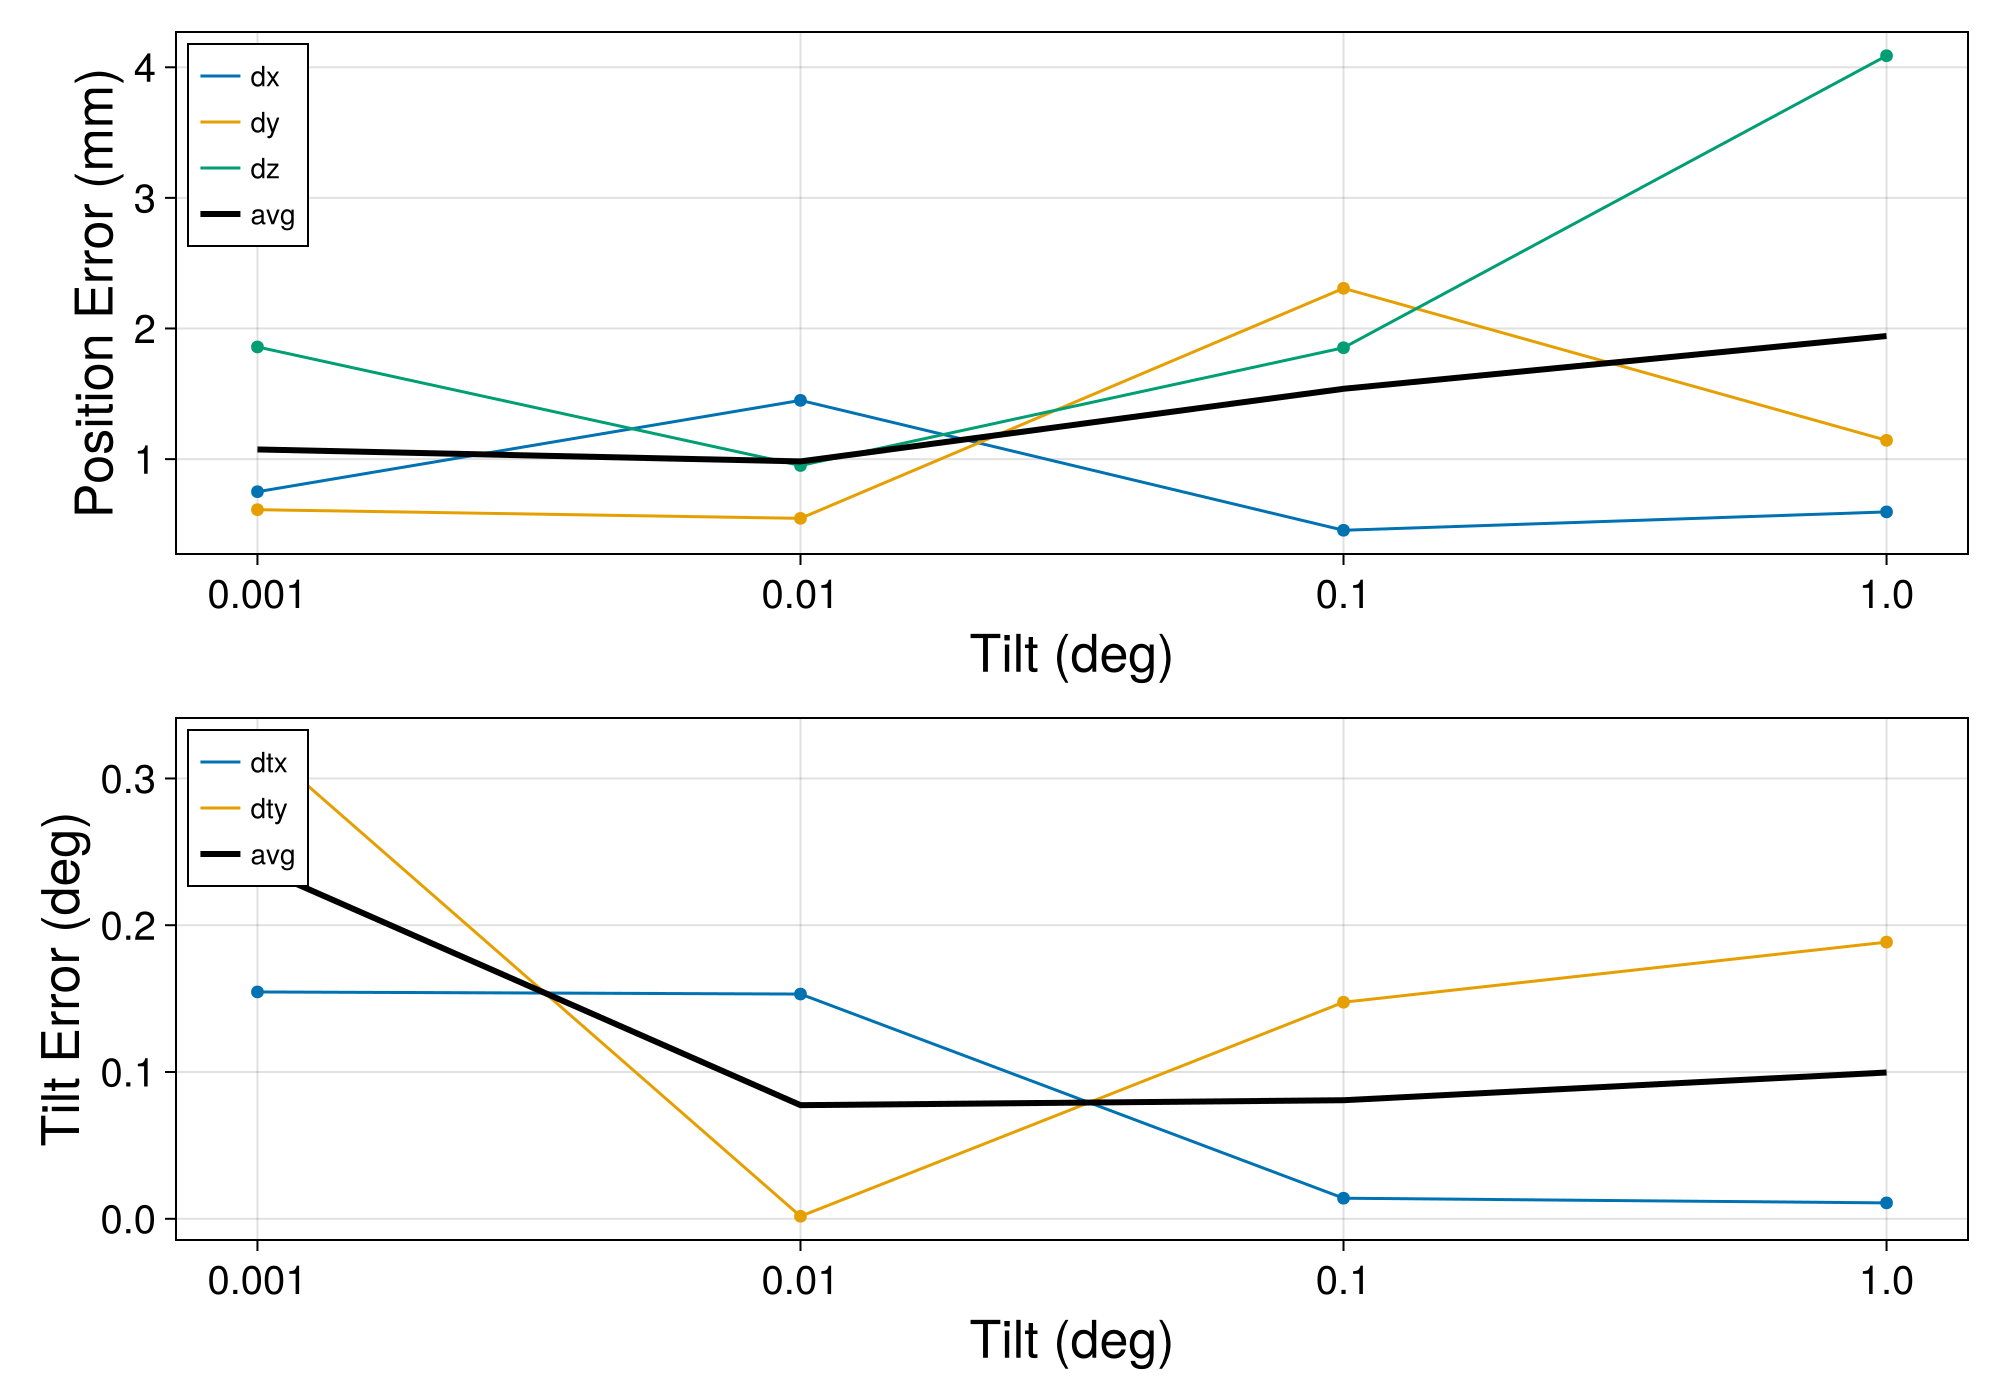

In [8]:
using CairoMakie

tilts = [.001, .01, .1, 1]

dx_mm  = Float64[]
dy_mm  = Float64[]
dz_mm  = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for tilt in tilts
    dr, phys, fld, ls = run_scan(
        shift_x=0,
        shift_y=0,
        shift_z=0,
        tilt_x_deg=tilt,
        tilt_y_deg=tilt,
        hall_r_inner_frac= 0.40,
        hall_r_outer_frac= 0.50,
        add_noise_frac = 0.01,
    )

    push!(dx_mm,  abs(fld.x0 - phys.x0 - 0) * 1e3)
    push!(dy_mm,  abs(fld.y0 - phys.y0 - 0) * 1e3)
    push!(dz_mm,  abs(fld.z0 - phys.z0 - 0) * 1e3)
    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - tilt))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - tilt))
end

x_mm = tilts # .* 1e3

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize=ax1.ylabelsize=ax2.xlabelsize=ax2.ylabelsize=26
ax1.xticklabelsize=ax1.yticklabelsize=ax2.xticklabelsize=ax2.yticklabelsize=20

# position components
lines!(ax1, x_mm, dx_mm, label="dx")
scatter!(ax1, x_mm, dx_mm)

lines!(ax1, x_mm, dy_mm, label="dy")
scatter!(ax1, x_mm, dy_mm)

lines!(ax1, x_mm, dz_mm, label="dz")
scatter!(ax1, x_mm, dz_mm)

lines!(ax1, x_mm, pos_avg, label="avg", linewidth=3, color=:black)


# tilt components
lines!(ax2, x_mm, dtx_deg, label="dtx")
scatter!(ax2, x_mm, dtx_deg)

lines!(ax2, x_mm, dty_deg, label="dty")
scatter!(ax2, x_mm, dty_deg)

lines!(ax2, x_mm, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/bursche/.julia/packages/Makie/kJl0u/src/scenes.jl:264


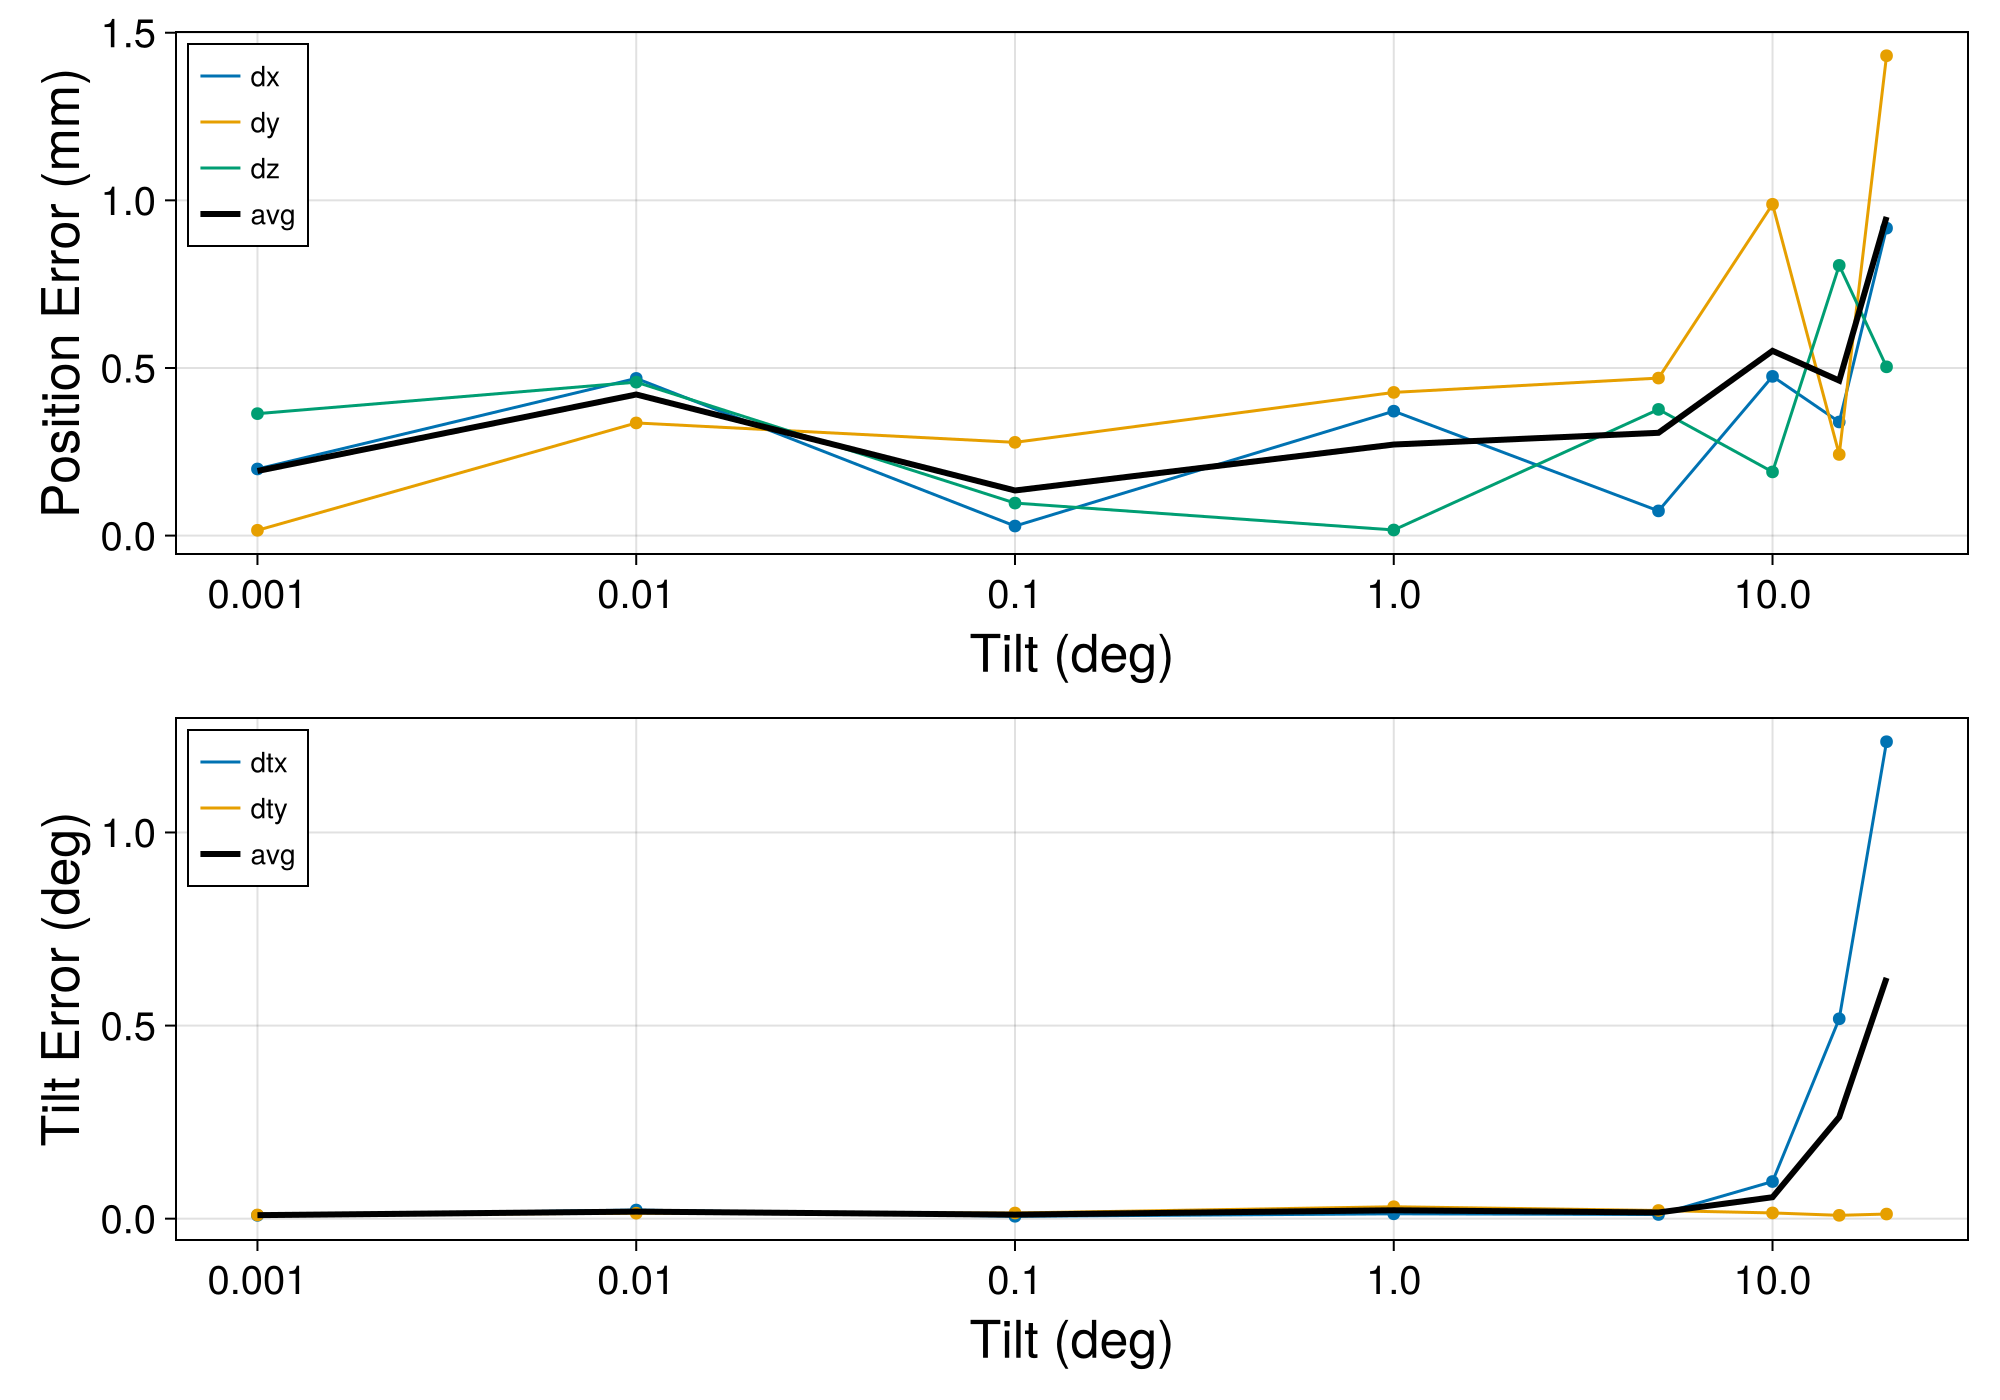

In [9]:
using CairoMakie

tilts = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20]

# ============================================================
# Errors (same structure as shift scan, but tilt sweep)
# ============================================================

dx_mm   = Float64[]
dy_mm   = Float64[]
dz_mm   = Float64[]
dtx_deg = Float64[]
dty_deg = Float64[]

for tilt in tilts

    dr, phys, fld = run_scan(
        shift_x = 0.0,
        shift_y = 0.0,
        shift_z = 0.0,

        tilt_x_deg = tilt,
        tilt_y_deg = tilt,

        add_noise_frac = 0.001,
    )

    push!(dx_mm,   abs(fld.x0 - phys.x0) * 1e3)
    push!(dy_mm,   abs(fld.y0 - phys.y0) * 1e3)
    push!(dz_mm,   abs(fld.z0 - phys.z0) * 1e3)

    push!(dtx_deg, abs(fld.tilt_x - phys.tilt_x - tilt))
    push!(dty_deg, abs(fld.tilt_y - phys.tilt_y - tilt))
end

x = tilts

pos_avg  = (dx_mm .+ dy_mm .+ dz_mm) ./ 3
tilt_avg = (dtx_deg .+ dty_deg) ./ 2

# ============================================================
# Figure (same layout as original shift version)
# ============================================================

fig = Figure(resolution=(1000,700))

ax1 = Axis(fig[1,1],
    xlabel="Tilt (deg)",
    ylabel="Position Error (mm)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax2 = Axis(fig[2,1],
    xlabel="Tilt (deg)",
    ylabel="Tilt Error (deg)",
    xscale=log10,
    xtickformat=x -> string.(round.(x; digits=6))
)

ax1.xlabelsize = ax1.ylabelsize = ax2.xlabelsize = ax2.ylabelsize = 26
ax1.xticklabelsize = ax1.yticklabelsize = ax2.xticklabelsize = ax2.yticklabelsize = 20

# ============================================================
# Position components
# ============================================================

lines!(ax1, x, dx_mm, label="dx")
scatter!(ax1, x, dx_mm)

lines!(ax1, x, dy_mm, label="dy")
scatter!(ax1, x, dy_mm)

lines!(ax1, x, dz_mm, label="dz")
scatter!(ax1, x, dz_mm)

lines!(ax1, x, pos_avg, label="avg", linewidth=3, color=:black)

# ============================================================
# Tilt components
# ============================================================

lines!(ax2, x, dtx_deg, label="dtx")
scatter!(ax2, x, dtx_deg)

lines!(ax2, x, dty_deg, label="dty")
scatter!(ax2, x, dty_deg)

lines!(ax2, x, tilt_avg, label="avg", linewidth=3, color=:black)

axislegend(ax1; position=:lt)
axislegend(ax2; position=:lt)

fig

In [ ]:
# Run Single Case - Full Output
results = run_coil_axis_comparison(
    run_name       = "sparc_pf1u",
    script_dir     = "./",
    coil_current_a = 100.0,
    field_hall_mode = :internal,s
    display_axis_plot = false,   # suppress readline() in notebook
    hall_r_inner_frac       = 0.40,
    hall_r_outer_frac       = 0.70,
    
)
println("Results: ", results.field_corrected)
# print results analysis x0 from sinavg
println("x0 from sinavg: ", results.field_analysis.sinavg.x0)